In [1]:
from ISMgas.fitting.systemic_redshift import Fitter
from ISMgas.SupportingFunctions import load_QFitsview_spectra, overlayAllLines
import matplotlib.pyplot as plt 

(3500.0, 5825.0)

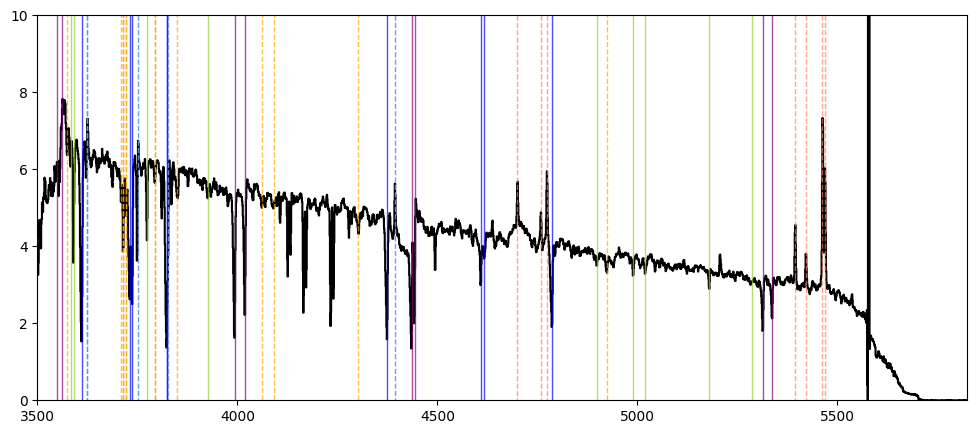

In [4]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec_nebem")

zs = 1.865 ## Guess redshift
overlayAllLines(zfactor = (1+zs))

flux *= 1e-2
## Make a mock error spectra
error_mock = flux*0.1
plt.ylim([0,10])
plt.xlim([3500, wave[-1]])

Running 1Running 2Running 0Running 10
Running 9Running 12

Running 11Running 13


Running 14


Running 6
Running 4Running 3

Running 5
Running 7
Running 8
Running 15
Running 16
Running 17
Running 18
Running 19


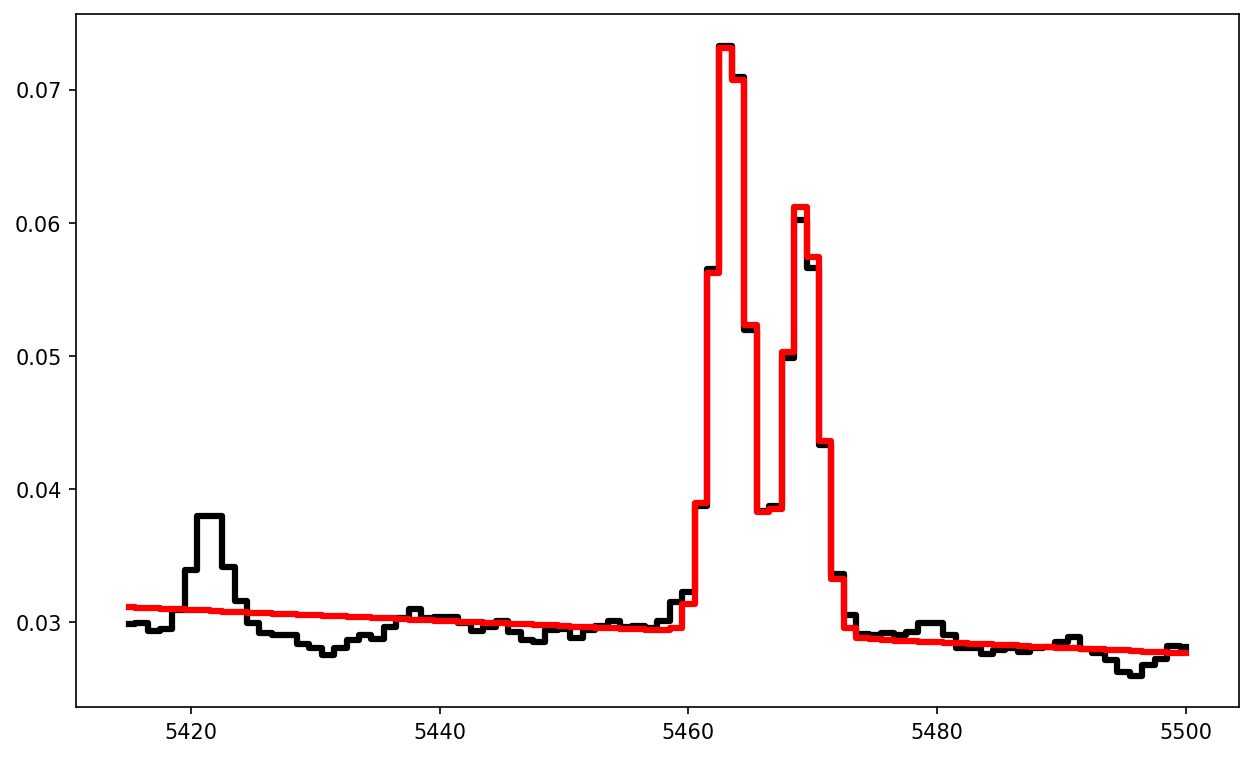

In [7]:
zFit = Fitter(
    wave = wave,
    flux= flux,
    err = error_mock,
    zs = zs,
    objid = 'test'
)
priors = {
            'p0':{'value':0.0001, 'min':0, 'max':0.1},
            'p1':{'value':0.0001, 'min':0, 'max':0.1},
            'p2':{'value':-0.001, 'min':-1, 'max':1},
            'p3':{'value':-0.001, 'min':-1, 'max':1},
            'z1':{'value':zs, 'min':zs - 0.001, 'max':zs + 0.001},
            'sigma1':{'value':0.0001,   'min':0.0, 'max':0.0005}
        }

results = zFit.neb1908(niter=20, plotting=True, priors=priors)

In [8]:
results

{'best_fit': {'zneb': [1.8653947685693697, 5.3817039029459945e-05],
  'sigma_neb': [0.00013609345207822308, 2.9373491388405603e-06],
  'p0': [0.045857946471809644, 0.002575135461256944],
  'p1': [0.03291052632225112, 0.00185108044485929],
  'p2': [0.6440912266864806, 0.0010168926309781254],
  'p3': [-0.21492491267446406, 0.06325058403869852],
  'wave': <Column name='Wave' dtype='float64' length=86>
  5415.0
  5416.0
  5417.0
  5418.0
  5419.0
  5420.0
  5421.0
  5422.0
  5423.0
     ...
  5493.0
  5494.0
  5495.0
  5496.0
  5497.0
  5498.0
  5499.0
  5500.0,
  'flux': <Column name='Flux' dtype='float64' length=86>
        0.029876612136
        0.029954998928
        0.029366733923
  0.029517311238000003
         0.03093411007
        0.033905214369
  0.037987672156999996
         0.03797881688
        0.034170392068
                   ...
  0.027714575077000002
  0.027128789631000003
        0.026293574646
        0.025967005443
        0.026752733741
        0.027255055904
        0.

(5375.0, 5500.0)

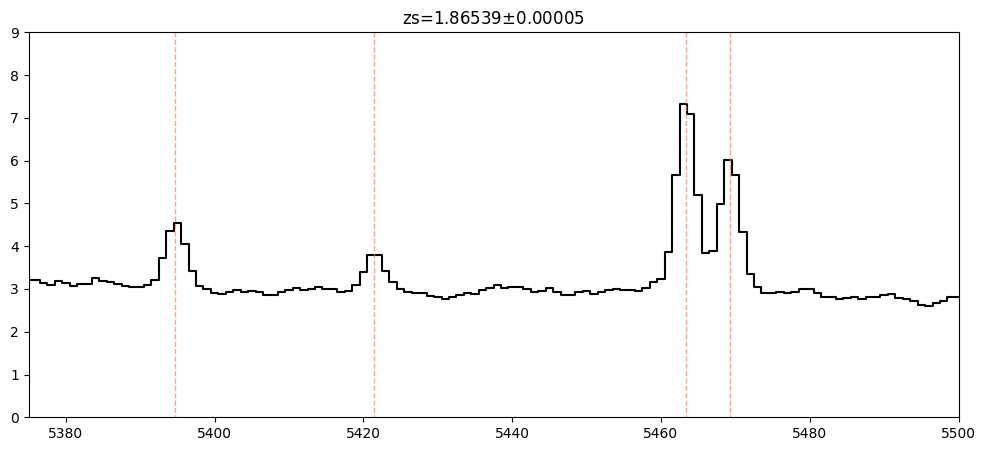

In [17]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec_nebem")

zs = results['best_fit']['zneb'][0] ## best fit redshift
zsErr = results['best_fit']['zneb'][1] ## error

overlayAllLines(zfactor = (1+zs))
plt.title(f"zs={zs:.5f}$\pm${zsErr:.5f}")
plt.ylim([0,9])
plt.xlim([5375, 5500])